In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sympy import *
import matplotlib.pyplot as plt
import random as rand
import time as tm
init_printing(use_latex=True)
filename = "Data/TestDataLots.xlsx"
# My functions:
from SolveRMSETikhonov import SolveRMSETikhonov
from TikhonovOLDSolve import TikhonovOLDSolve
from TikhonovNEWSolve import TikhonovNEWSolve
from TikhonovNEWSolveRMSE import TikhonovNEWSolveRMSE
from TikhonovNEWSolveRowReduce import TikhonovNEWSolveRowReduce

from mealpy import FloatVar, SMA, ABC, ALO

Time elapsed for NEW2: 0.6849708557128906 seconds, RMSE was 2.03057511233268


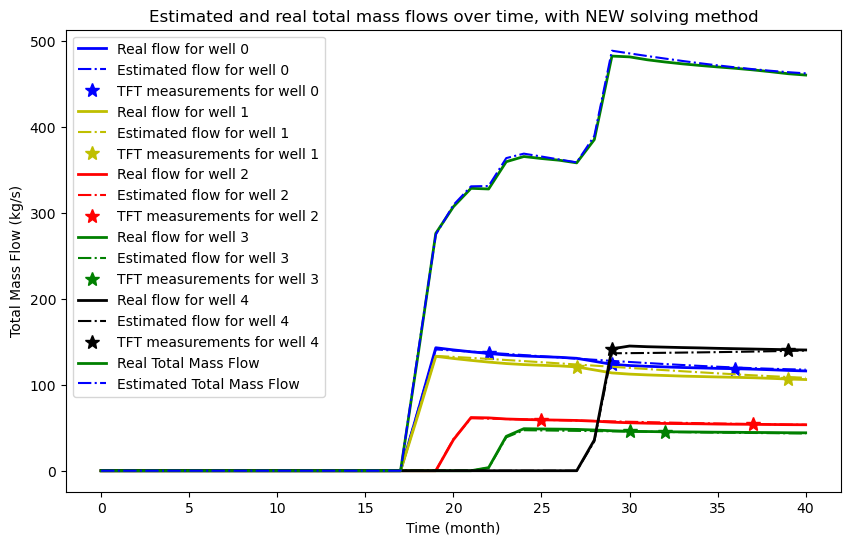

In [2]:
k = 5

# Test for new method
start_time2 = tm.time()
RMSE, _ = TikhonovNEWSolveRowReduce(filename, k=k, Lambda1=1, Lambda2=2, Lambda3=3, suppress=False)
end_time2 = tm.time()
elapsed_time2 = end_time2 - start_time2
print(f'Time elapsed for NEW2: {elapsed_time2} seconds, RMSE was {RMSE}')

In [3]:
# Logarithmic Grid Search of lambda values
k = 5

Lambdas = [2, 8, 20, 50, 100, 300, 800, 2000] #np.linspace(0, nLambdas**4, num=nLambdas)

nLambdas = len(Lambdas)
print(Lambdas)


[2, 8, 20, 50, 100, 300, 800, 2000]


In [4]:
# Grid Search

numRuns = 20 # Num runs on each test (results averaged between this many)
RMSEs = np.zeros((nLambdas, nLambdas, nLambdas))
seeds = np.random.randint(10**10, size=numRuns)   # Use same random seeds for each set of runs.
# for h in range(nLambdas):
#     for i in range(nLambdas):
#         for j in range(nLambdas):
#             res = []
#             for run in range(numRuns):
#                 rand.seed(int(seeds[run]))
#                 RMSE, _ = TikhonovNEWSolveRowReduce(filename, pTrain, pTest, k=k, Lambda1=Lambdas[h], Lambda2=Lambdas[i], Lambda3=Lambdas[j], suppress=True)
#                 res.append(RMSE)
#             RMSEs[h,i,j] = np.mean(res)
#print(RMSEs)

In [5]:
# Metaheuristic Search Function
# seeds = np.random.randint(10**10, size=numRuns)   # Use same random seeds for each set of runs.

def LLSO_MH(solution):
    l1, l2, l3 = solution
    k = 5
    res = []
    filename = "TestDataLots.xlsx"
    RMSE, _ = TikhonovNEWSolveRowReduce(filename, k=k, Lambda1=l1, Lambda2=l2, Lambda3=l3, suppress=True)
    #print(np.mean(res))
    return RMSE

In [7]:
# Metaheuristic Search
# Import PSO
from pyMetaheuristic.algorithm import particle_swarm_optimization

# OR Define your Custom Function. The function input should be a list of values, 
# each value representing a dimension (x1, x2, ...xn) of the problem.

# Run PSO
parameters = {
    'swarm_size': 300,
    'min_values': (100, 2, 0),
    'max_values': (300, 15, 1),
    'iterations': 50,
    'decay': 0,
    'w': 0.9,
    'c1': 2,
    'c2': 2,
    'verbose': True,
    'start_init': None,
    'target_value': None
}
pso = particle_swarm_optimization(target_function = LLSO_MH, **parameters)

# Print Solution
variables = pso[:-1]
minimum   = pso[ -1]
print('Variables: ', np.around(variables, 4) , ' Minimum Value Found: ', round(minimum, 4) )



Iteration =  0  f(x) =  1.25886965528858
Iteration =  1  f(x) =  1.25886965528858
Iteration =  2  f(x) =  1.25821732395993
Iteration =  3  f(x) =  1.25821224104772
Iteration =  4  f(x) =  1.25821224104772
Iteration =  5  f(x) =  1.25821224104772
Iteration =  6  f(x) =  1.25821224104772
Iteration =  7  f(x) =  1.25821224104772
Iteration =  8  f(x) =  1.25821224104772
Iteration =  9  f(x) =  1.25820967071200
Iteration =  10  f(x) =  1.25820967071200
Iteration =  11  f(x) =  1.25820191213867
Iteration =  12  f(x) =  1.25820176131464
Iteration =  13  f(x) =  1.25820176131464
Iteration =  14  f(x) =  1.25820176131464
Iteration =  15  f(x) =  1.25820174376855
Iteration =  16  f(x) =  1.25820174376855
Iteration =  17  f(x) =  1.25820174376855
Iteration =  18  f(x) =  1.25820174376855
Iteration =  19  f(x) =  1.25820174293558
Iteration =  20  f(x) =  1.25820174293558
Iteration =  21  f(x) =  1.25820174293558
Iteration =  22  f(x) =  1.25820174293558
Iteration =  23  f(x) =  1.25820174293558
It

TypeError: loop of ufunc does not support argument 0 of type float which has no callable rint method

In [ ]:
print('Variables: ', variables , ' Minimum Value Found: ', round(minimum, 4) )


In [ ]:

# Plot Solution
from pyMetaheuristic.utils import graphs
plot_parameters = {
    'min_values': (0, 0, 0, 0),
    'max_values': (200, 200, 200, 10),
    'step': (0.1, 0.1, 0.1, 0.1),
    'solution': [variables],
    'proj_view': '3D',
    'view': 'browser'
}
graphs.plot_single_function(target_function = LLSO_MH, **plot_parameters)

In [7]:
Numerical Optimisation of Params From Here?
Will be very different based on sample data.

SyntaxError: invalid syntax (443056260.py, line 2)

In [4]:
pTrain = 10
pTest = 20
Lambdas = [50]
i=0
j=0
k=3

RMSE, _ = TikhonovNEWSolveRMSE(filename, pTrain, pTest, k=k, TikLambda1=Lambdas[i], TikLambda2=Lambdas[j], suppress=True)
RMSE

In [ ]:
pip install mealPy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.3/386.3 kB 16.4 MB/s eta 0:00:00
     ━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/13.0 MB 153.6 MB/s eta 0:00:01